In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [4]:
 df = pd.read_csv("DATA/Crop_recommendation.csv")

In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (2200, 8)

Column names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data types:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

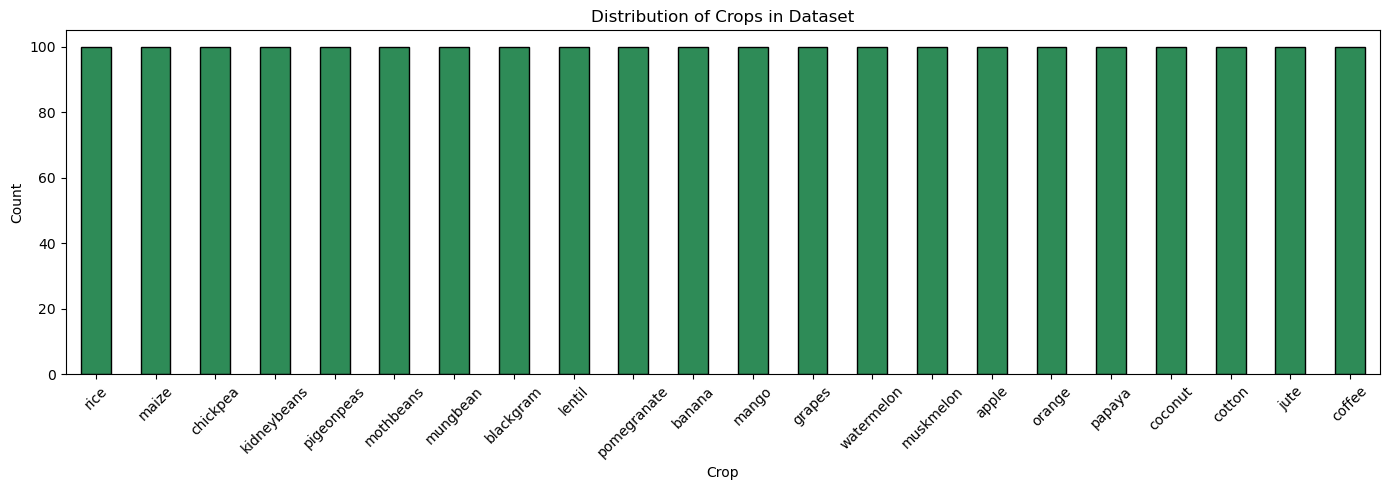

In [9]:
plt.figure(figsize=(14, 5))
df['label'].value_counts().plot(kind='bar', color='seagreen', edgecolor='black')
plt.title("Distribution of Crops in Dataset")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

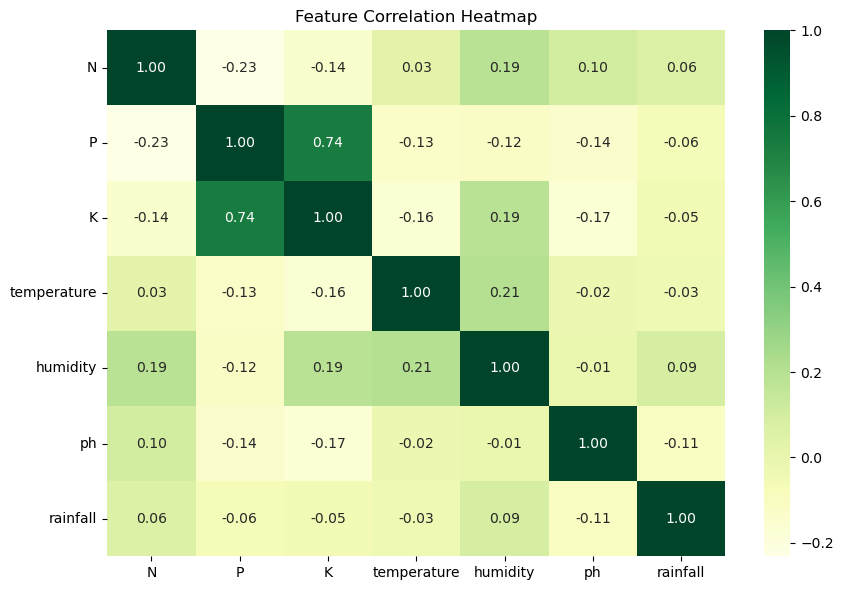

In [10]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='YlGn', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

C:\Users\Parth\AppData\Local\Temp\ipykernel_16632\1667722678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='label', y=col, ax=ax, palette='Set2')
C:\Users\Parth\AppData\Local\Temp\ipykernel_16632\1667722678.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Parth\AppData\Local\Temp\ipykernel_16632\1667722678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='label', y=col, ax=ax, palette='Set2')
C:\Users\Parth\AppData\Local\Temp\ipykernel_16632\1667722678.py:8: UserWarning: set_ticklabels() should only be u

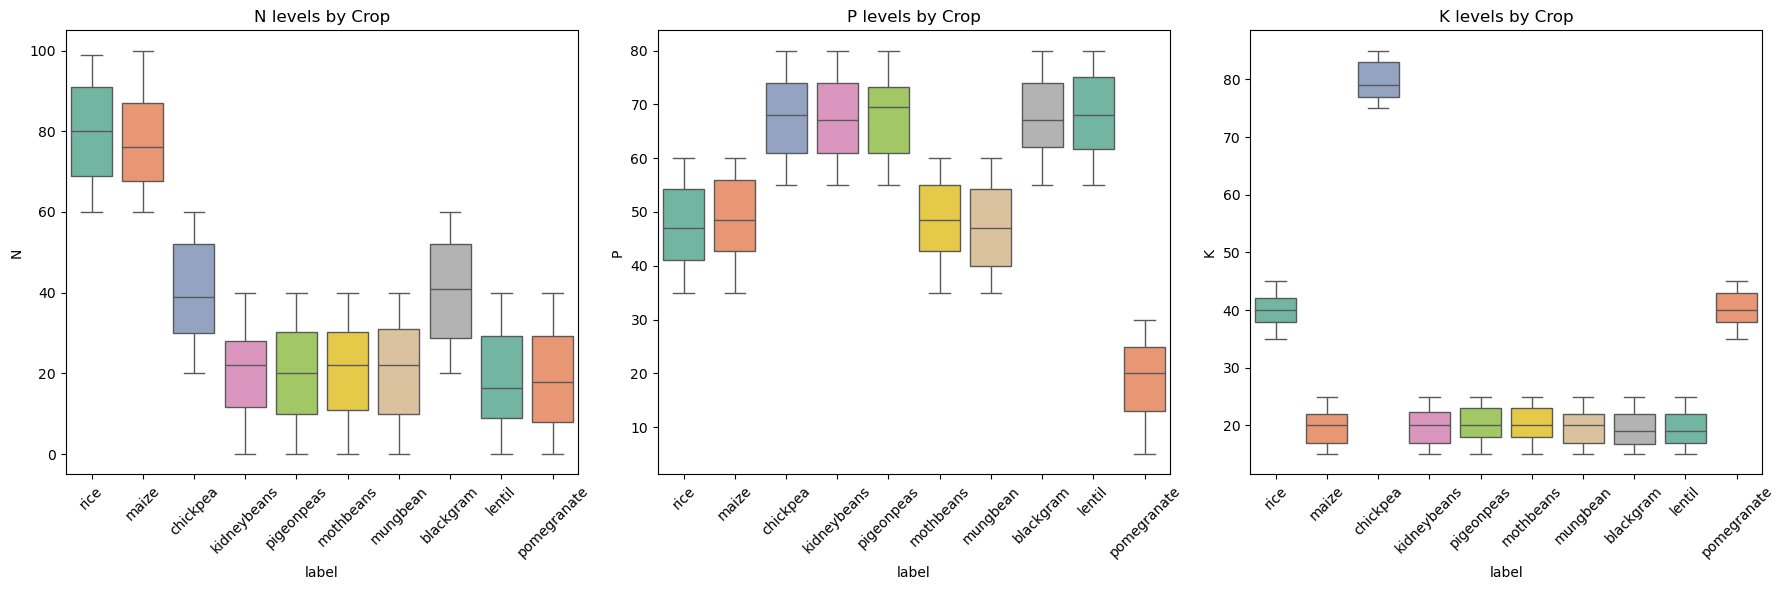

In [11]:
top_crops = df['label'].value_counts().head(10).index
df_top = df[df['label'].isin(top_crops)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, ['N', 'P', 'K']):
    sns.boxplot(data=df_top, x='label', y=col, ax=ax, palette='Set2')
    ax.set_title(f"{col} levels by Crop")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

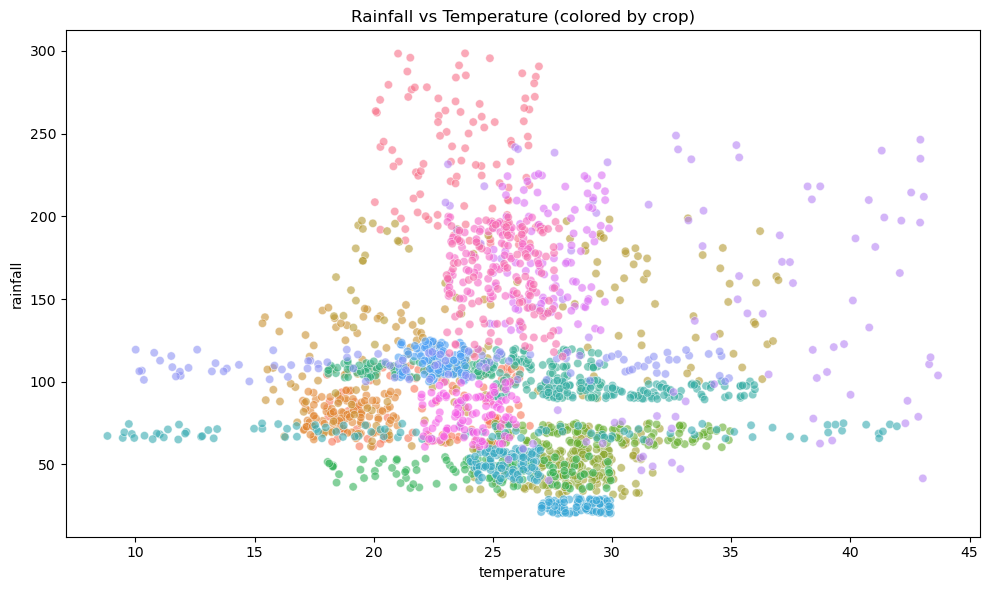

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature', y='rainfall', hue='label', alpha=0.6, legend=False)
plt.title("Rainfall vs Temperature (colored by crop)")
plt.tight_layout()
plt.show()

In [13]:
# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Encode crop names to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features to same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nCrop name mapping (first 5):")
for i in range(5):
    print(f"  {i} → {le.classes_[i]}")

Training samples: 1760
Testing samples: 440

Crop name mapping (first 5):
  0 → apple
  1 → banana
  2 → blackgram
  3 → chickpea
  4 → coconut


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                 SVC(kernel='rbf', probability=True),
    "KNN":                 KNeighborsClassifier(n_neighbors=5)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = round(acc * 100, 2)
    trained_models[name] = model
    print(f"{name:<25} Accuracy: {acc*100:.2f}%")

best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} ({results[best_model_name]}%)")

Logistic Regression       Accuracy: 97.27%
Random Forest             Accuracy: 99.55%
SVM                       Accuracy: 98.41%
KNN                       Accuracy: 97.95%

Best Model: Random Forest (99.55%)


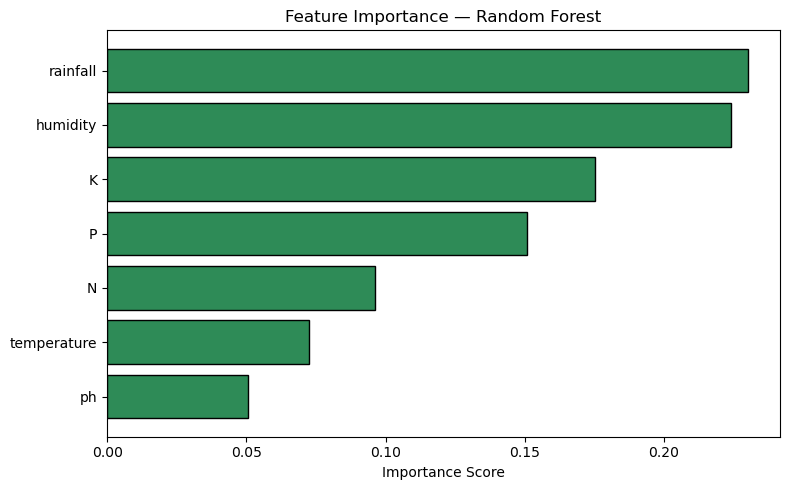

       Feature  Importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


In [15]:
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='seagreen', edgecolor='black')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(fi_df.sort_values('Importance', ascending=False))

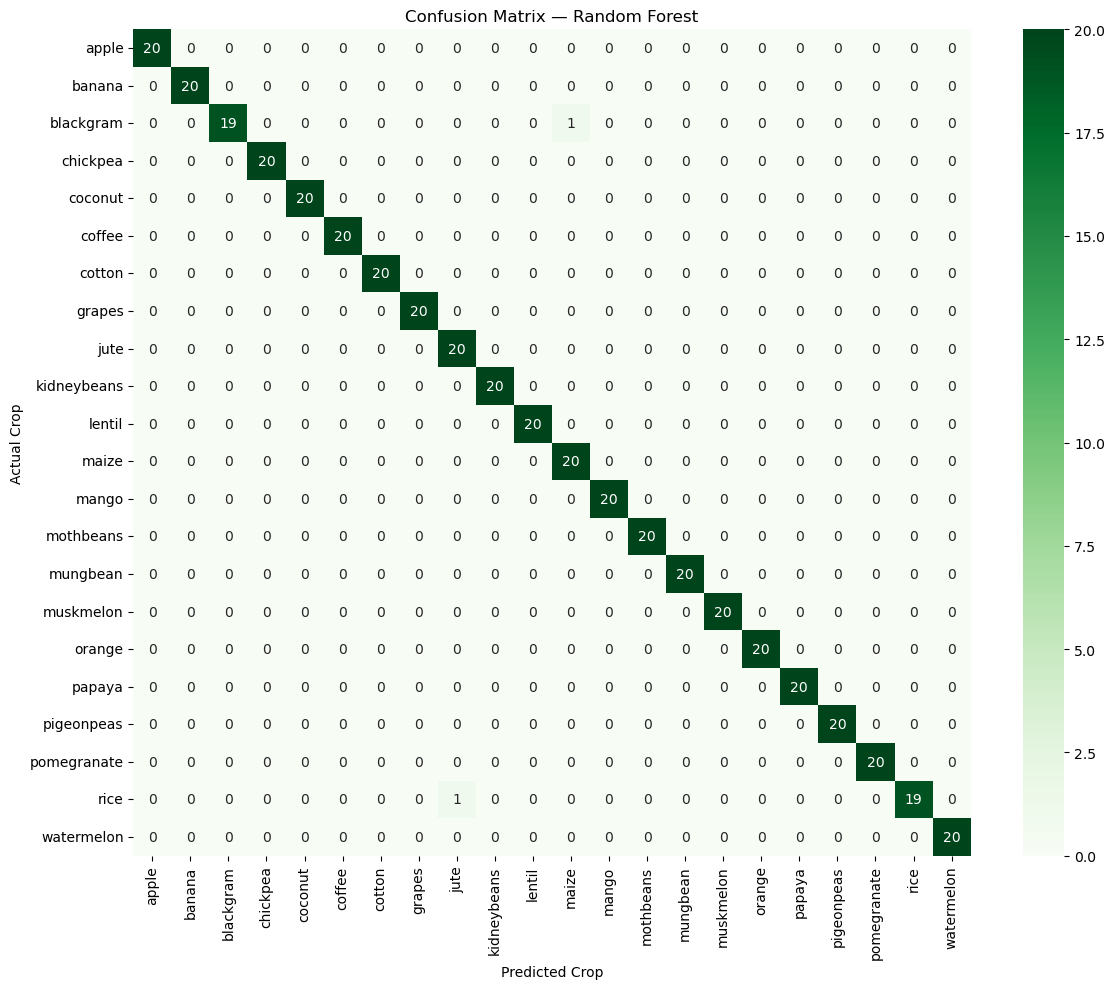

In [16]:
y_pred_best = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

    Rainfall Recommended Crop
0         20        muskmelon
1         40       watermelon
2         60       watermelon
3         80             jute
4        100             jute
5        120             jute
6        140             jute
7        160             jute
8        180             jute
9        200             rice
10       220             rice
11       240             rice
12       260             rice
13       280             rice
14       300             rice


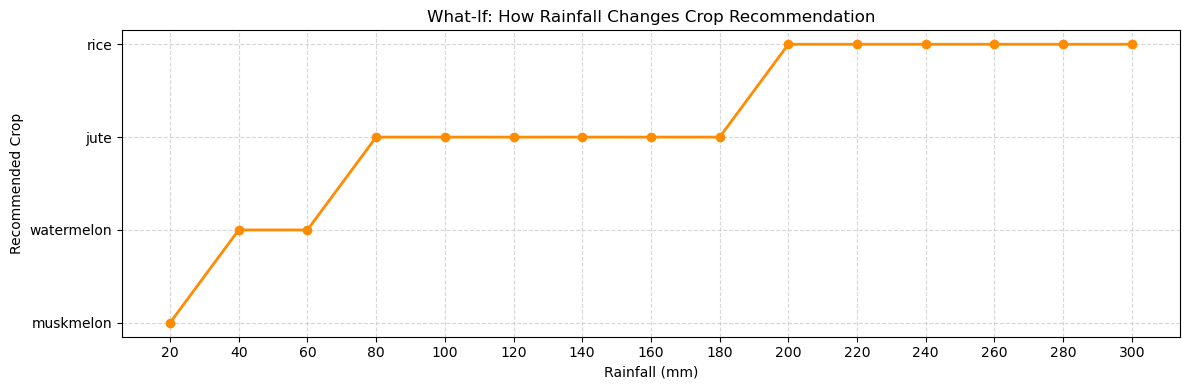

In [17]:
# Base input — average "rice-like" conditions
base_input = {'N': 90, 'P': 42, 'K': 43, 'temperature': 25,
               'humidity': 80, 'ph': 6.5, 'rainfall': 200}

# Vary rainfall from 20 to 300
rainfall_range = np.arange(20, 301, 20)
predictions = []

for r in rainfall_range:
    test = base_input.copy()
    test['rainfall'] = r
    row = pd.DataFrame([test])[X.columns]
    row_scaled = scaler.transform(row)
    pred_encoded = rf_model.predict(row_scaled)[0]
    pred_label = le.inverse_transform([pred_encoded])[0]
    predictions.append(pred_label)

whatif_df = pd.DataFrame({'Rainfall': rainfall_range, 'Recommended Crop': predictions})
print(whatif_df)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(rainfall_range, predictions, marker='o', color='darkorange', linewidth=2)
plt.title("What-If: How Rainfall Changes Crop Recommendation")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Recommended Crop")
plt.xticks(rainfall_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
import os
os.makedirs("model", exist_ok=True)

with open("model/crop_model.pkl", "wb") as f:
    pickle.dump({
        "model": rf_model,
        "scaler": scaler,
        "label_encoder": le,
        "features": X.columns.tolist()
    }, f)

print("Model saved successfully!")

Model saved successfully!
